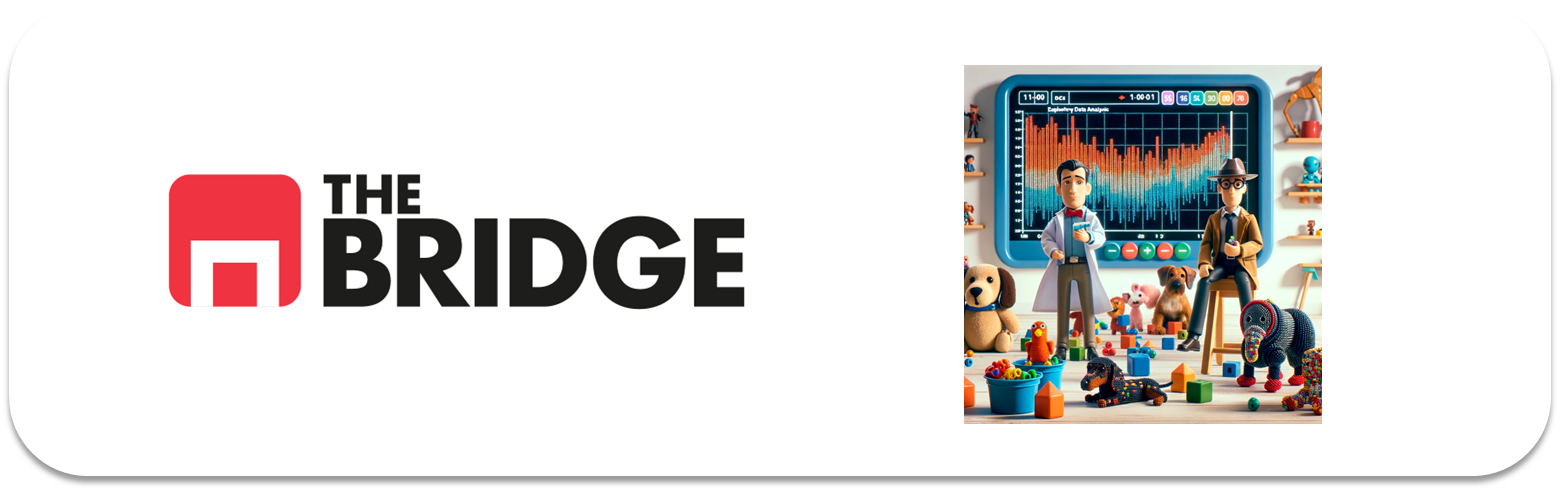

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys
!{sys.executable} -m pip install scipy scikit-learn pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 9.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 10.3 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- --------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import scipy, sklearn, pandas, numpy, matplotlib, seaborn
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)

scipy: 1.17.1
sklearn: 1.8.0
pandas: 3.0.2


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr, shapiro, normaltest
from scipy.stats import f_oneway, kruskal

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [8]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [9]:
df = df.drop(columns=["deck", "survived", "pclass", "embarked"])
df.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [10]:
df["family_members"] = df["parch"] + df["sibsp"]

df = df.drop(columns=["parch", "sibsp"])

df.head()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [12]:
moda = df["embark_town"].mode()[0]
df["embark_town"] = df["embark_town"].fillna(moda)

In [13]:
print(df["embark_town"].isnull().sum())
print(df["embark_town"].value_counts())

0
embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [14]:
df["age"] = df["age"].fillna(df["age"].mean())

In [16]:
print(df.groupby("who")["age"].mean())

df["age"] = df.groupby("who")["age"].transform(
    lambda x: x.fillna(x.mean())
)

who
child     6.369518
man      32.370932
woman    31.550012
Name: age, dtype: float64


In [17]:
print(f"Nulos restantes en age: {df['age'].isnull().sum()}")
print(df.groupby("who")["age"].describe())

Nulos restantes en age: 0
       count       mean        std    min   25%        50%   75%   max
who                                                                   
child   83.0   6.369518   4.729063   0.42   2.0   5.000000   9.5  15.0
man    537.0  32.370932  11.410368  16.00  25.0  29.699118  36.0  80.0
woman  271.0  31.550012  10.346087  16.00  24.0  29.699118  36.0  63.0


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [19]:
print(df.columns.tolist())
print(df["alive"].value_counts())

['sex', 'age', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'family_members']
alive
no     549
yes    342
Name: count, dtype: int64


In [21]:
df["survived_bin"] = (df["alive"] == "yes").astype(int)

print(df["survived_bin"].value_counts())

survived_bin
0    549
1    342
Name: count, dtype: int64


In [22]:
print(df.groupby("who")["survived_bin"].agg(["sum", "mean"]).rename(columns={"sum":"absoluto","mean":"tasa"}))

       absoluto      tasa
who                      
child        49  0.590361
man          88  0.163873
woman       205  0.756458


       absoluto      tasa
who                      
child        49  0.590361
man          88  0.163873
woman       205  0.756458


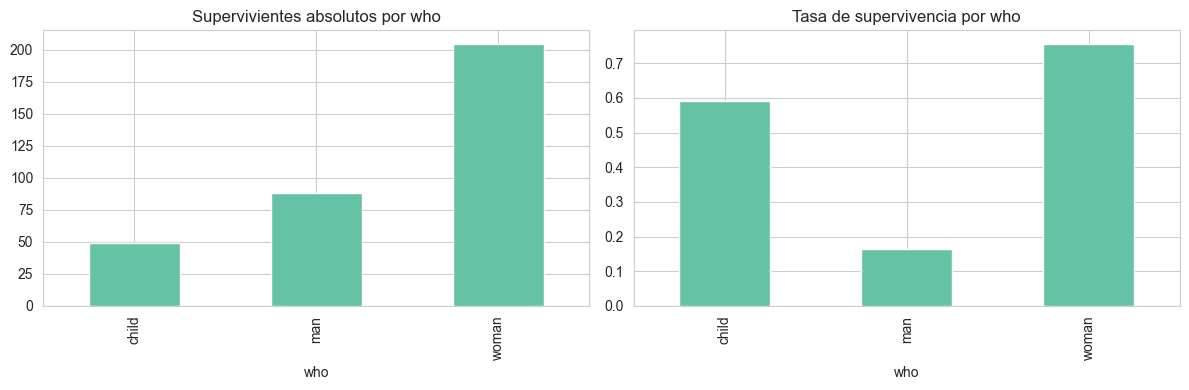


Chi² sexo vs survived: chi2=260.717, p=0.0000 → Significativo
Chi² niño vs survived: chi2=15.557, p=0.0001 → Significativo


In [23]:
# Absolutos y relativos
print(df.groupby("who")["survived_bin"].agg(["sum", "mean"]).rename(columns={"sum":"absoluto","mean":"tasa"}))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("who")["survived_bin"].sum().plot(kind="bar", ax=axes[0], title="Supervivientes absolutos por who")
df.groupby("who")["survived_bin"].mean().plot(kind="bar", ax=axes[1], title="Tasa de supervivencia por who")
plt.tight_layout()
plt.show()

# Test chi-cuadrado: sexo vs supervivencia
ct_sex = pd.crosstab(df["sex"], df["alive"])
chi2, p, dof, expected = chi2_contingency(ct_sex)
print(f"\nChi² sexo vs survived: chi2={chi2:.3f}, p={p:.4f} → {'Significativo' if p < 0.05 else 'No significativo'}")

# Test chi-cuadrado: adulto/niño vs supervivencia
df["is_child"] = df["who"] == "child"
ct_child = pd.crosstab(df["is_child"], df["alive"])
chi2c, pc, _, _ = chi2_contingency(ct_child)
print(f"Chi² niño vs survived: chi2={chi2c:.3f}, p={pc:.4f} → {'Significativo' if pc < 0.05 else 'No significativo'}")

        absoluto      tasa
class                     
First        136  0.629630
Second        87  0.472826
Third        119  0.242363

Chi² clase vs survived: chi2=102.889, p=0.0000 → Significativo


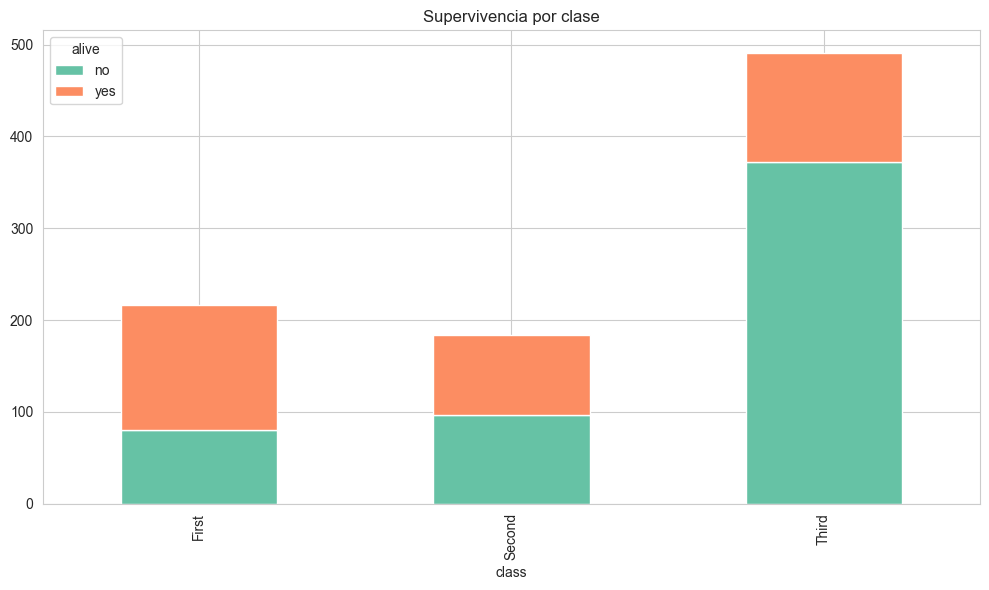

In [24]:
print(df.groupby("class")["survived_bin"].agg(["sum","mean"]).rename(columns={"sum":"absoluto","mean":"tasa"}))

ct_class = pd.crosstab(df["class"], df["alive"])
chi2_cl, p_cl, _, _ = chi2_contingency(ct_class)
print(f"\nChi² clase vs survived: chi2={chi2_cl:.3f}, p={p_cl:.4f} → {'Significativo' if p_cl < 0.05 else 'No significativo'}")

ct_class.plot(kind="bar", stacked=True, title="Supervivencia por clase")
plt.tight_layout(); plt.show()

In [25]:
print(df.groupby("embark_town")["survived_bin"].agg(["sum","mean"]).rename(columns={"sum":"absoluto","mean":"tasa"}))

ct_town = pd.crosstab(df["embark_town"], df["alive"])
chi2_t, p_t, _, _ = chi2_contingency(ct_town)
print(f"\nChi² embark_town vs survived: chi2={chi2_t:.3f}, p={p_t:.4f} → {'Significativo' if p_t < 0.05 else 'No significativo'}")

             absoluto      tasa
embark_town                    
Cherbourg          93  0.553571
Queenstown         30  0.389610
Southampton       219  0.339009

Chi² embark_town vs survived: chi2=25.964, p=0.0000 → Significativo


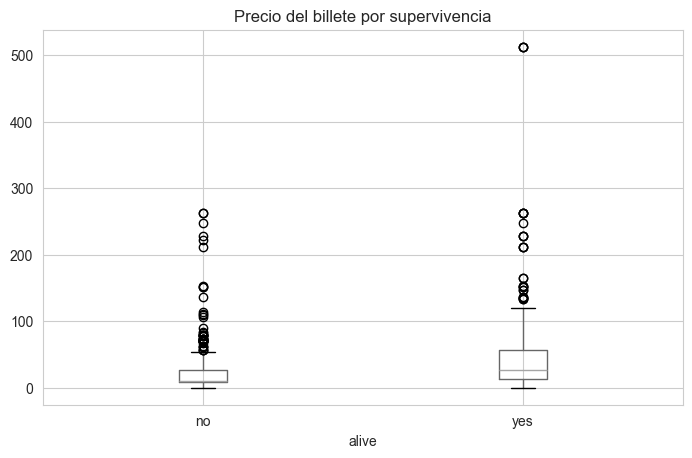

Mann-Whitney U fare: stat=129951.5, p=0.0000 → Significativo


In [27]:
df.boxplot(column="fare", by="alive", figsize=(8,5))
plt.title("Precio del billete por supervivencia"); plt.suptitle(""); plt.show()

survived_fare = df[df["alive"] == "yes"]["fare"]
dead_fare     = df[df["alive"] == "no"]["fare"]
stat, p_fare = stats.mannwhitneyu(survived_fare, dead_fare, alternative="two-sided")
print(f"Mann-Whitney U fare: stat={stat:.1f}, p={p_fare:.4f} → {'Significativo' if p_fare < 0.05 else 'No significativo'}")

In [32]:
print(df.columns.tolist())

['sex', 'age', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'family_members', 'survived_bin', 'is_child', 'age_group']


In [35]:
gratis = df[df["fare"] == 0]
print(f"Pasajeros con fare=0: {len(gratis)}")


print(gratis.to_string())

Pasajeros con fare=0: 15
      sex        age  fare   class  who  adult_male  embark_town alive  alone  family_members  survived_bin  is_child age_group
179  male  36.000000   0.0   Third  man        True  Southampton    no   True               0             0     False    adulto
263  male  40.000000   0.0   First  man        True  Southampton    no   True               0             0     False    adulto
271  male  25.000000   0.0   Third  man        True  Southampton   yes   True               0             1     False    adulto
277  male  29.699118   0.0  Second  man        True  Southampton    no   True               0             0     False    adulto
302  male  19.000000   0.0   Third  man        True  Southampton    no   True               0             0     False    adulto
413  male  29.699118   0.0  Second  man        True  Southampton    no   True               0             0     False    adulto
466  male  29.699118   0.0  Second  man        True  Southampton    no   True  

In [36]:
cols = ["who", "class", "embark_town", "alive", "fare"]

gratis = df[df["fare"] == 0]
print(f"Pasajeros con fare=0: {len(gratis)}")
print(gratis[cols].to_string())

max_fare = df[df["fare"] == df["fare"].max()]
print(f"\nPasajero con fare más alto: {df['fare'].max():.2f}")
print(max_fare[cols].to_string())

Pasajeros con fare=0: 15
     who   class  embark_town alive  fare
179  man   Third  Southampton    no   0.0
263  man   First  Southampton    no   0.0
271  man   Third  Southampton   yes   0.0
277  man  Second  Southampton    no   0.0
302  man   Third  Southampton    no   0.0
413  man  Second  Southampton    no   0.0
466  man  Second  Southampton    no   0.0
481  man  Second  Southampton    no   0.0
597  man   Third  Southampton    no   0.0
633  man   First  Southampton    no   0.0
674  man  Second  Southampton    no   0.0
732  man  Second  Southampton    no   0.0
806  man   First  Southampton    no   0.0
815  man   First  Southampton    no   0.0
822  man   First  Southampton    no   0.0

Pasajero con fare más alto: 512.33
       who  class embark_town alive      fare
258  woman  First   Cherbourg   yes  512.3292
679    man  First   Cherbourg   yes  512.3292
737    man  First   Cherbourg   yes  512.3292


alive               no        yes
embark_town                      
Cherbourg    35.443335  79.720926
Queenstown   13.335904  13.182227
Southampton  20.743987  39.916514


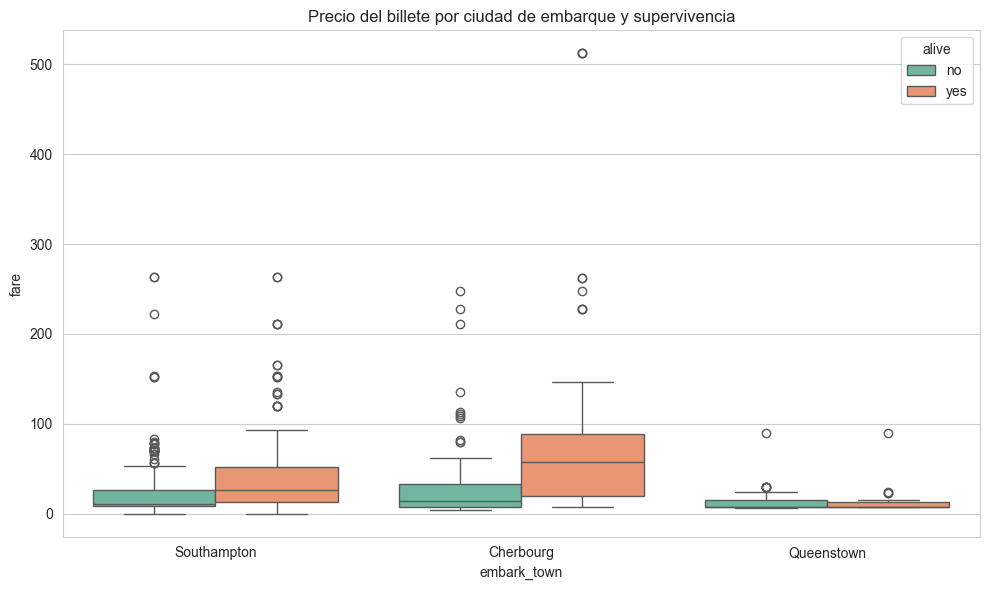

In [29]:
print(df.groupby(["embark_town","alive"])["fare"].mean().unstack())

sns.boxplot(data=df, x="embark_town", y="fare", hue="alive")
plt.title("Precio del billete por ciudad de embarque y supervivencia")
plt.tight_layout(); plt.show()

                    absoluto      tasa
class  age_group                      
First  niño                3  0.750000
       adolescente        11  0.916667
       adulto            119  0.639785
       mayor               3  0.214286
Second niño               17  1.000000
       adolescente         6  0.500000
       adulto             63  0.414474
       mayor               1  0.333333
Third  niño               20  0.416667
       adolescente        13  0.282609
       adulto             85  0.216837
       mayor               1  0.200000


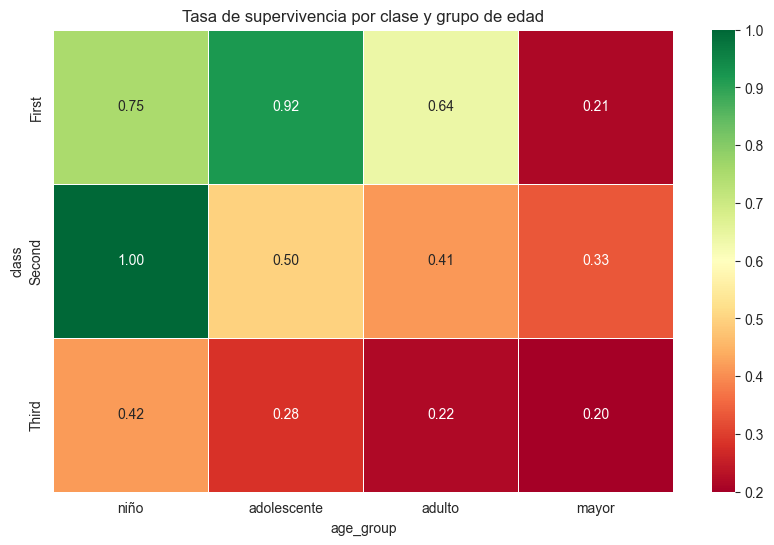

In [30]:
df["age_group"] = pd.cut(df["age"], bins=[0,12,18,60,100], labels=["niño","adolescente","adulto","mayor"])

tabla = df.groupby(["class","age_group"])["survived_bin"].agg(["sum","mean"]).rename(columns={"sum":"absoluto","mean":"tasa"})
print(tabla)

pivot = df.groupby(["class","age_group"])["survived_bin"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5)
plt.title("Tasa de supervivencia por clase y grupo de edad")
plt.show()

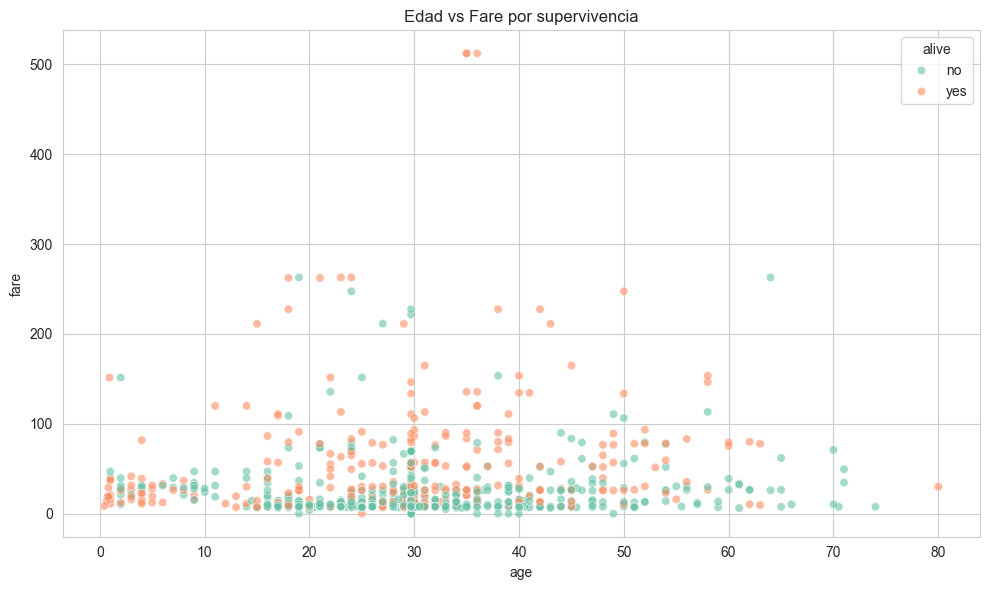

Correlación age-fare (no): r=0.069, p=0.1054
Correlación age-fare (yes): r=0.154, p=0.0043


In [31]:
sns.scatterplot(data=df, x="age", y="fare", hue="alive", alpha=0.6)
plt.title("Edad vs Fare por supervivencia")
plt.tight_layout(); plt.show()

for grupo, g in df.groupby("alive"):
    r, p = pearsonr(g["age"].dropna(), g.loc[g["age"].notna(), "fare"])
    print(f"Correlación age-fare ({grupo}): r={r:.3f}, p={p:.4f}")

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?